## Exo1

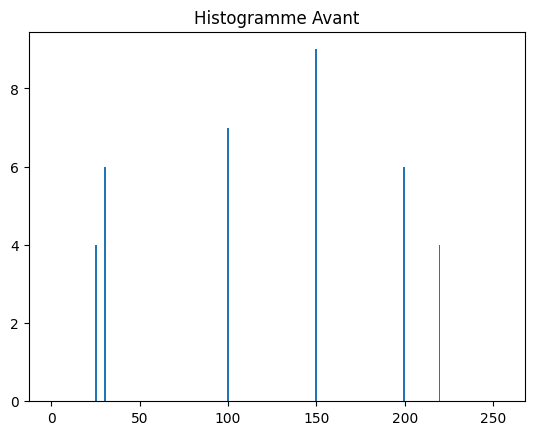

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# matrice de niveaux de gris)
image = np.array([
    [25, 100, 220, 220,200, 150],
    [200, 30, 30,30,220,100],
    [220, 200, 30,30,100,150],
    [150, 150, 150, 200,150,150],
    [100, 200, 30, 200,150,150],
    [100, 100, 100,25,25,25]
])

# Calcul de l’histogramme
histogram = np.bincount(image.flatten(), minlength=256)

#histogramme
plt.figure()
plt.hist(image.flatten(), bins=256, range=(0,255))
plt.title("Histogramme Avant")
plt.show()

Image après rehaussement :
[[  0  98 255 255 228 163]
 [228   6   6   6 255  98]
 [255 228   6   6  98 163]
 [163 163 163 228 163 163]
 [ 98 228   6 228 163 163]
 [ 98  98  98   0   0   0]]


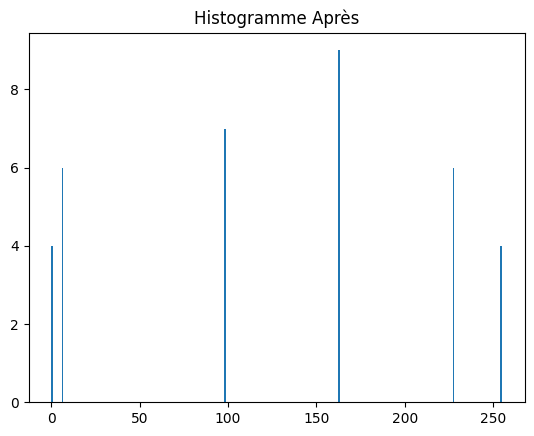

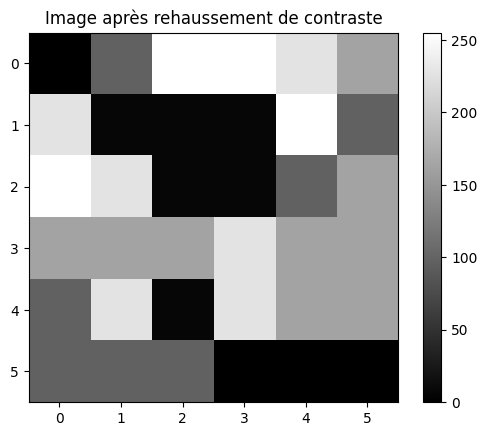

In [9]:
#2- rehaussement de contraste par la transfo linéaire

# Trouver min et max
Imin = image.min()
Imax = image.max()

# Transformation linéaire
image_contrast = ((image - Imin) / (Imax - Imin)) * 255

# Convertir en entier (image 8 bits)
image_contrast = image_contrast.astype(np.uint8)

print("Image après rehaussement :")
print(image_contrast)

# Histogramme après
plt.figure()
plt.hist(image_contrast.flatten(), bins=256, range=(0,255))
plt.title("Histogramme Après")
plt.show()

# Affichage de l'image après rehaussement
plt.imshow(image_contrast, cmap='gray', vmin=0, vmax=255)
plt.title("Image après rehaussement de contraste")
plt.colorbar()
plt.show()

## Exo2

Histogramme avant égalisation :
[0 1 2 3 4 5 6 7 8 7 6 5 4 3 2 1]

CDF cumulatif :
[ 0  1  3  6 10 15 21 28 36 43 49 54 58 61 63 64]

CDF normalisée (transformation ponctuelle) :
[ 0  0  0  1  2  3  5  6  8 10 11 13 14 14 15 15]

Image après égalisation :
[[ 0  0  1  5  8  8 11 11]
 [ 0  2  3  6  8 13 13 11]
 [ 1  3  6 10 14 14 13  8]
 [ 5  6 10 15 15 14 10  6]
 [ 8  8 14 14 15 10  6  5]
 [ 8 13 14 14 10  3  5  3]
 [11 11 13 10  6  5  2  2]
 [10 11  8  6  5  3  2  1]]

Histogramme après égalisation :
[3 3 4 5 0 6 7 0 8 0 7 6 0 5 7 3]


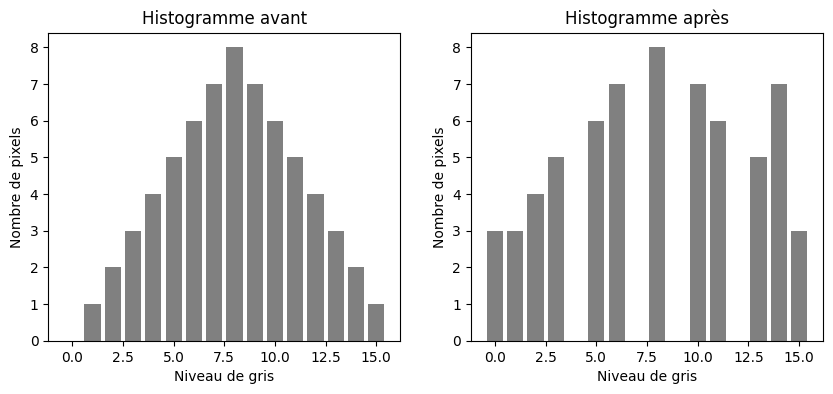

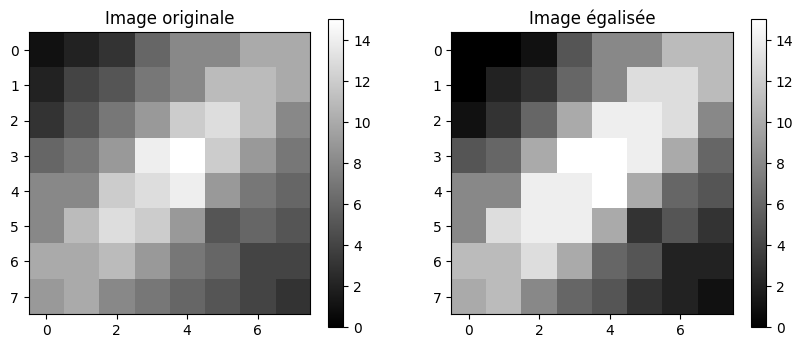

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Image donnée (N=16)
image = np.array([
    [1, 2, 3, 6, 8, 8,10,10],
    [2, 4, 5,7,8,11,11,10],
    [3, 5, 7,9,12,13,11,8],
    [6, 7, 9, 14,15,12,9,7],
    [8, 8, 12, 13,14,9,7,6],
    [8, 11, 13,12,9,5,6,5],
    [10, 10, 11,9,7,6,4,4],
    [9, 10, 8,7,6,5,4,3]
], dtype=np.uint8)

N_levels = 16  # niveaux 0..15
N_pixels = image.size

# 1️⃣ Histogramme avant
hist_before, bins = np.histogram(image.flatten(), bins=N_levels, range=(0, N_levels-1))
print("Histogramme avant égalisation :")
print(hist_before)

# 2️⃣ CDF
cdf = hist_before.cumsum()
print("\nCDF cumulatif :")
print(cdf)

# 3️⃣ Normalisation de la CDF pour utiliser toute la plage
cdf_min = cdf[cdf > 0][0]
cdf_normalized = np.round((cdf - cdf_min) / (N_pixels - cdf_min) * (N_levels - 1))
cdf_normalized = cdf_normalized.astype(np.uint8)
print("\nCDF normalisée (transformation ponctuelle) :")
print(cdf_normalized)

# 4️⃣ Transformation ponctuelle : image égalisée
image_eq = cdf_normalized[image]
print("\nImage après égalisation :")
print(image_eq)

# 5️⃣ Histogramme après
hist_after, _ = np.histogram(image_eq.flatten(), bins=N_levels, range=(0, N_levels-1))
print("\nHistogramme après égalisation :")
print(hist_after)

# 6️⃣ Affichage des histogrammes
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(range(N_levels), hist_before, color='gray')
plt.title("Histogramme avant")
plt.xlabel("Niveau de gris")
plt.ylabel("Nombre de pixels")

plt.subplot(1,2,2)
plt.bar(range(N_levels), hist_after, color='gray')
plt.title("Histogramme après")
plt.xlabel("Niveau de gris")
plt.ylabel("Nombre de pixels")

plt.show()

# 7️⃣ Affichage des images
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image, cmap='gray', vmin=0, vmax=N_levels-1)
plt.title("Image originale")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(image_eq, cmap='gray', vmin=0, vmax=N_levels-1)
plt.title("Image égalisée")
plt.colorbar()

plt.show()

## Exo3

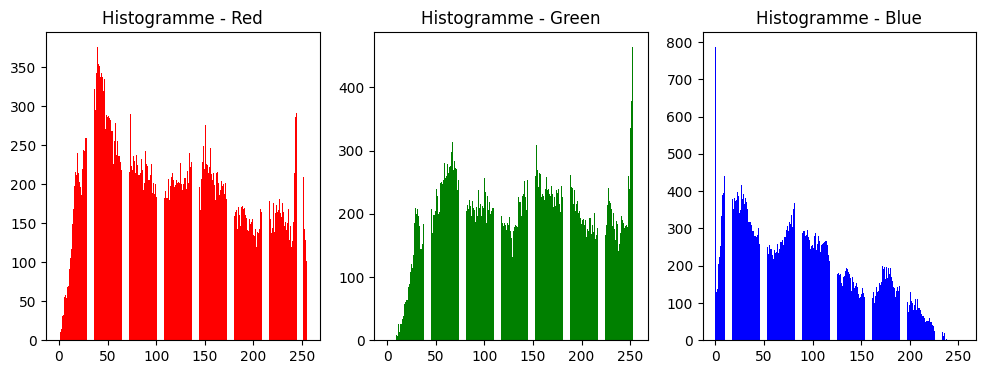

In [17]:
from PIL import Image

# Charger une image couleur (RGB)
img = Image.open("C:\\Users\\Dell\\Downloads\\Photo.jpg").convert("RGB")
img_array = np.array(img)

# Séparer les canaux
R = img_array[:,:,0]
G = img_array[:,:,1]
B = img_array[:,:,2]

# Calculer les histogrammes
hist_R, _ = np.histogram(R.flatten(), bins=256, range=(0,255))
hist_G, _ = np.histogram(G.flatten(), bins=256, range=(0,255))
hist_B, _ = np.histogram(B.flatten(), bins=256, range=(0,255))

# Afficher les histogrammes
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.bar(range(256), hist_R, color='red')
plt.title("Histogramme - Red")

plt.subplot(1,3,2)
plt.bar(range(256), hist_G, color='green')
plt.title("Histogramme - Green")

plt.subplot(1,3,3)
plt.bar(range(256), hist_B, color='blue')
plt.title("Histogramme - Blue")

plt.show()